<a href="https://colab.research.google.com/github/elariekerboull/master_uppsala/blob/main/Machine%20Learning/Exercise_7_3_CIFAR_10_DenseNet_solution_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from keras.models import Model
from keras.layers import (
    Input,  # we inport the layers directly to save some space later.
    Dense,
    Dropout,
    Activation,
    Convolution2D,
    AveragePooling2D,
    GlobalAveragePooling2D,
    concatenate)
from keras.regularizers import l2
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

In [ ]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green, blue).

In [ ]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])


def normalize(images):
    mean = np.mean(images, axis=0)[np.newaxis]  # shape = (1, 32, 32, 3)
    sigma = np.std(images, axis=0)[np.newaxis]  # shape = (1, 32, 32, 3)
    images_normalized = (images - mean) / sigma
    return images_normalized

# normalize each pixel and color-channel separately across all images
# take 2000 images for validation from test data
x_train_norm = normalize(x_train)
x_test_norm = normalize(x_test)[:8000]
x_valid_norm = normalize(x_test)[8000:]

# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

170508288/170498071 [==============================] - 2s 0us/step
images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


The following functions define the DenseNet architecture. It uses a different way to use the KERAS API where the output of each layer is explicitely passed to the next layer. This allows to stack together (concacenate) the outputs from multiple layers.

Consider this simple example
```
x = Conv2D(10, (2,2), paddig="same")
y = Conv2D(10, 2,2), paddig="same")
z = concatenate(x, y)
...
```
Here, the output of the first convolution layer is combined with the result from the second convolution layer.

We start with a fully connected network

In [ ]:
from tensorflow import keras
layers = keras.layers

def dense_block(x, n=8):
  """ Create a block of n densely connected pairs of convolutions """
  xlist = [x]
  for i in range(n):
    x = layers.Conv2D(8, (3, 3), padding='same', activation='relu')(x)
    xlist.append(x)
    x = layers.concatenate(xlist[:], axis=-1)
  return x

x0 = Input(shape=(32, 32, 3), name='input') # some tensor of shape say (n, nx, ny, 64)
x = dense_block(x0, 4)
x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = layers.AveragePooling2D((2, 2), strides=(2, 2))(x)
x = dense_block(x)
x = layers.Conv2D(64, (1, 1), padding='same', activation='relu')(x)
x = layers.AveragePooling2D((2, 2), strides=(2, 2))(x)
x = dense_block(x)
x = GlobalAveragePooling2D(name='final_globalpooling')(x)
x = Dense(10, activation='softmax')(x)
model = keras.models.Model(inputs=[x0], outputs=[x], name='DenseNet')

In [ ]:
print(model.summary())

Model: "DenseNet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input (InputLayer)              [(None, 32, 32, 3)]  0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 32, 32, 8)    224         input[0][0]                      
__________________________________________________________________________________________________
concatenate (Concatenate)       (None, 32, 32, 11)   0           input[0][0]                      
                                                                 conv2d[0][0]                     
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 32, 32, 8)    800         concatenate[0][0]         

In [ ]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=32,
    epochs=20,
    verbose=1,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

Epoch 1/20
1563/1563 [==============================] - 105s 47ms/step - loss: 1.5614 - accuracy: 0.4177 - val_loss: 1.2917 - val_accuracy: 0.5295
Epoch 2/20
1563/1563 [==============================] - 72s 46ms/step - loss: 1.1176 - accuracy: 0.5992 - val_loss: 1.0132 - val_accuracy: 0.6250
Epoch 3/20
1563/1563 [==============================] - 72s 46ms/step - loss: 0.9351 - accuracy: 0.6684 - val_loss: 0.9144 - val_accuracy: 0.6645
Epoch 4/20
1563/1563 [==============================] - 72s 46ms/step - loss: 0.8248 - accuracy: 0.7068 - val_loss: 0.8509 - val_accuracy: 0.6970
Epoch 5/20
1563/1563 [==============================] - 72s 46ms/step - loss: 0.7427 - accuracy: 0.7395 - val_loss: 0.7467 - val_accuracy: 0.7400
Epoch 6/20
1563/1563 [==============================] - 72s 46ms/step - loss: 0.6729 - accuracy: 0.7636 - val_loss: 0.6746 - val_accuracy: 0.7620
Epoch 7/20
1563/1563 [==============================] - 72s 46ms/step - loss: 0.6160 - accuracy: 0.7831 - val_loss: 0.6807 

In [ ]:
print("Model performance :")
headers = ["", "Loss", "Accuracy"]

table = [
    ["Train", *model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128)],
    ["Validation", *model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128)],
    ["Test", *model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128)],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |     Loss |   Accuracy |
|------------+----------+------------|
| Train      | 0.229107 |   0.91782  |
| Validation | 0.687479 |   0.8005   |
| Test       | 0.696576 |   0.798625 |


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).


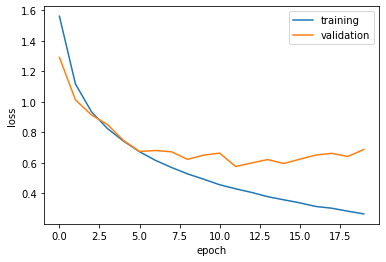

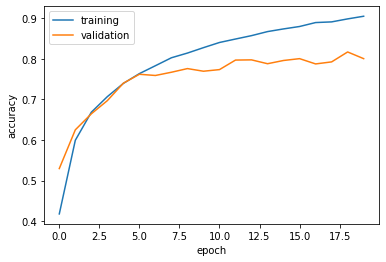

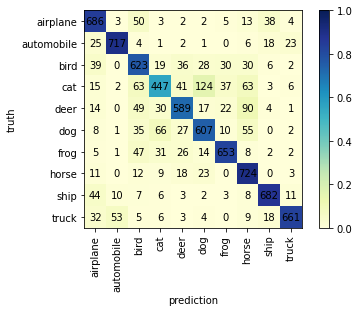

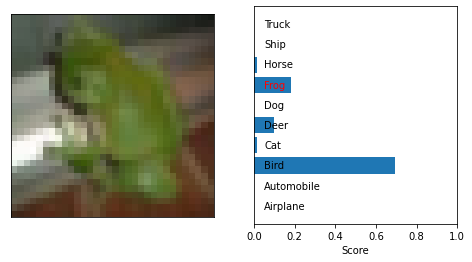

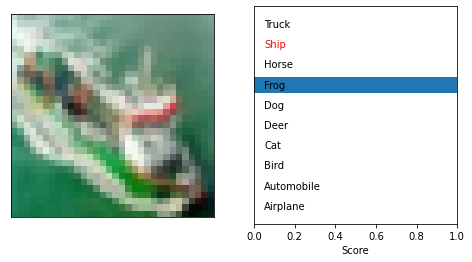

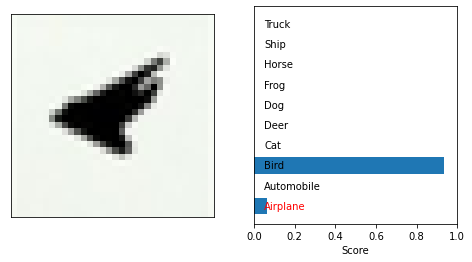

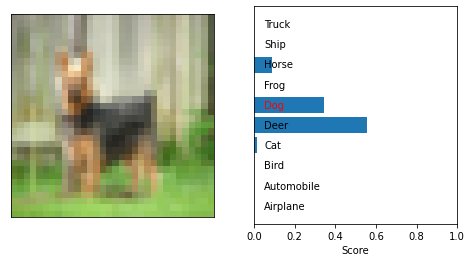

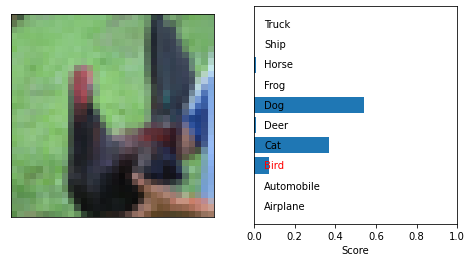

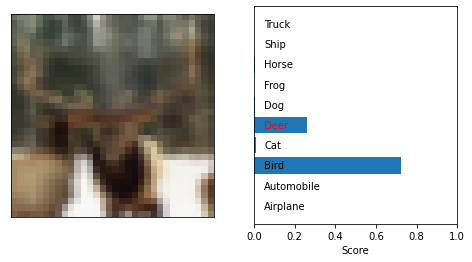

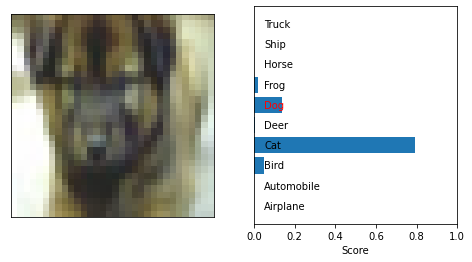

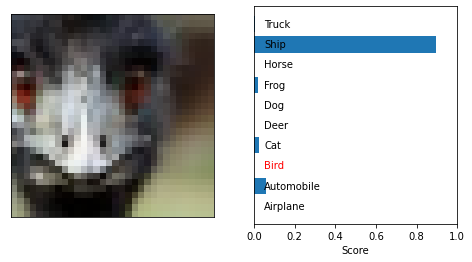

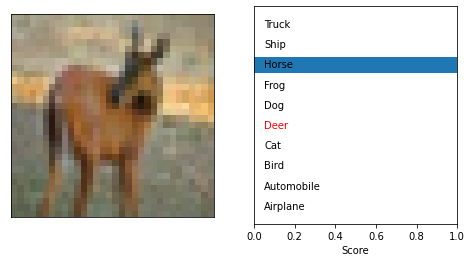

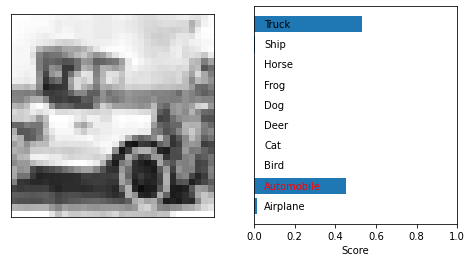

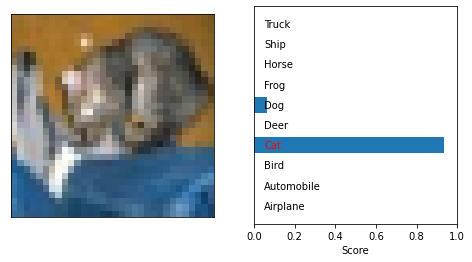

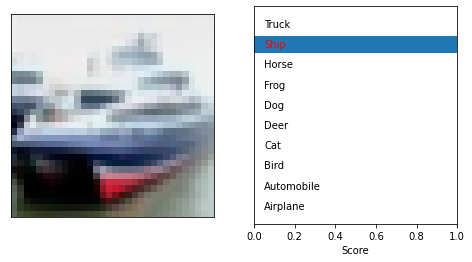

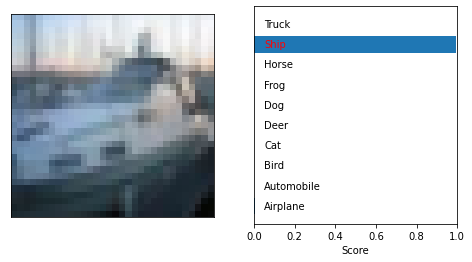

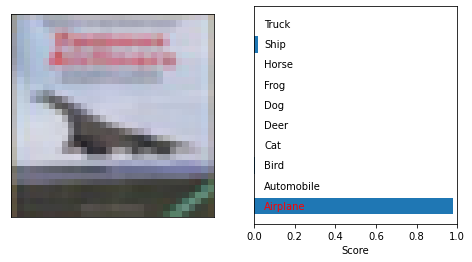

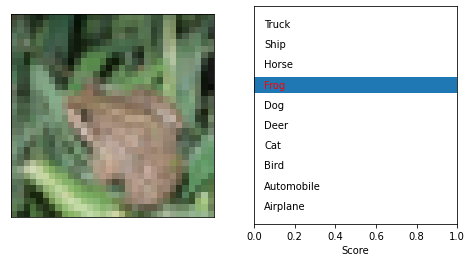

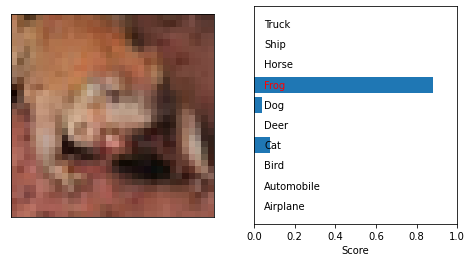

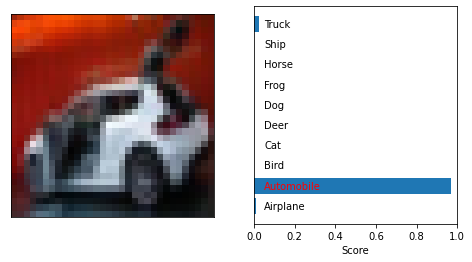

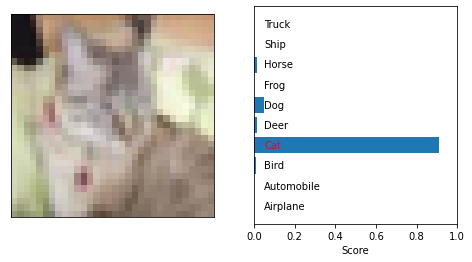

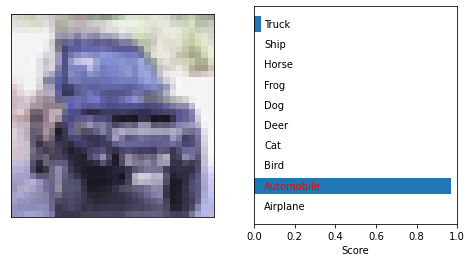

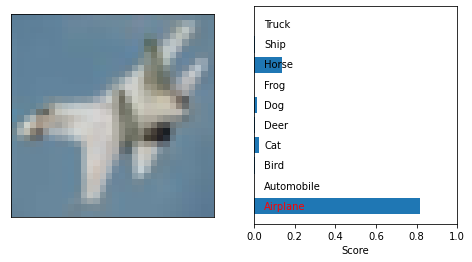

In [ ]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)

fig, ax = plt.subplots(1)
ax.plot(history["epoch"], history["loss"], label="training")
ax.plot(history["epoch"], history["val_loss"], label="validation")
ax.legend()
ax.set(xlabel="epoch", ylabel="loss")

fig, ax = plt.subplots(1)
ax.plot(history["epoch"], history["accuracy"], label="training")
ax.plot(history["epoch"], history["val_accuracy"], label="validation")
ax.legend()
ax.set(xlabel="epoch", ylabel="accuracy")

# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(
    y_test_cl, y_predict_cl
)

# compare prediction and truth
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# plot first 10 false classifications
for i in i0[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

# plot first 10 correct classifications
for i in i1[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])
